# 1. Dataset, lector y verificaciones:

## 1.1 Imports, descarga, extracción y lectura previa de datos:

In [35]:
#Imports 
from pathlib import Path
import pandas as pd

import time
import requests
import re
import sqlite3
from datetime import datetime, timezone
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

# Official SPARC data source
SPARC_URL = "https://astroweb.case.edu/SPARC/Rotmod_LTG.zip"

# Project directories
DATA_DIR = Path("data")
RAW_DIR = DATA_DIR / "raw"
EXTRACT_DIR = RAW_DIR / "Rotmod_LTG"

# ZIP file path
ZIP_PATH = RAW_DIR / "Rotmod_LTG.zip"

# Create directories if they do not exist
RAW_DIR.mkdir(parents=True, exist_ok=True)
EXTRACT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Raw data directory: {RAW_DIR.resolve()}")
print(f"Extraction directory: {EXTRACT_DIR.resolve()}")
print(f"ZIP path: {ZIP_PATH.resolve()}")

Raw data directory: /home/ronal/Computational-Astrophysics/SQL_Sparc_Project/data/raw
Extraction directory: /home/ronal/Computational-Astrophysics/SQL_Sparc_Project/data/raw/Rotmod_LTG
ZIP path: /home/ronal/Computational-Astrophysics/SQL_Sparc_Project/data/raw/Rotmod_LTG.zip


In [36]:
#Definir la descarga e intentos
def download_file(url, destination, max_retries=3):
    """
    Download a file using streaming and automatic retries.

    Parameters
    ----------
    url : str
        URL of the file to download.

    destination : pathlib.Path
        Local path where the file will be saved.

    max_retries : int
        Maximum number of download attempts.
    """

    headers = {
        "User-Agent": (
            "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
            "AppleWebKit/537.36 "
            "Chrome/149.0 Safari/537.36"
        )
    }

    for attempt in range(1, max_retries + 1):

        try:
            print(f"Download attempt {attempt}/{max_retries}...")

            with requests.get(
                url,
                headers=headers,
                stream=True,
                timeout=(30, 300)
            ) as response:

                response.raise_for_status()

                total_size = int(
                    response.headers.get("content-length", 0)
                )

                downloaded = 0

                with open(destination, "wb") as file:

                    for chunk in response.iter_content(
                        chunk_size=1024 * 1024
                    ):
                        if chunk:
                            file.write(chunk)
                            downloaded += len(chunk)

                            if total_size > 0:
                                progress = 100 * downloaded / total_size

                                print(
                                    f"\rDownloading: {progress:6.2f}%",
                                    end=""
                                )

            print("\nDownload completed successfully.")
            print(f"Saved to: {destination}")

            return

        except requests.exceptions.RequestException as error:

            print(f"\nDownload attempt failed: {error}")

            # Delete an incomplete download
            if destination.exists():
                destination.unlink()

            if attempt == max_retries:
                raise RuntimeError(
                    "Failed to download the SPARC dataset "
                    f"after {max_retries} attempts."
                ) from error

            print("Retrying in 5 seconds...")
            time.sleep(5)


#Descarga del ZIP
if ZIP_PATH.exists():
    print(f"ZIP file already exists: {ZIP_PATH}")

else:
    print("Downloading SPARC rotation-curve data...")

    download_file(
        SPARC_URL,
        ZIP_PATH,
        max_retries=3
    )


#Extracción del ZIP 
dat_files = list(EXTRACT_DIR.rglob("*.dat"))

if dat_files:
    print("Dataset has already been extracted.")
else:
    print("Extracting SPARC data...")

    with zipfile.ZipFile(ZIP_PATH, "r") as zip_ref:
        zip_ref.extractall(EXTRACT_DIR)

    print("Extraction completed successfully.")


#Verificación de datos descargados
dat_files = sorted(EXTRACT_DIR.rglob("*.dat"))

if len(dat_files) == 0:
    raise FileNotFoundError(
        "No .dat files were found after extracting the ZIP archive."
    )

print(f"Number of .dat files found: {len(dat_files)}")

print("\nFirst five files:")
for file_path in dat_files[:5]:
    print(file_path.name)


#Inspeccionar archivos 
sample_file = dat_files[0]

print(f"Inspecting file: {sample_file.name}")
print("-" * 70)

with open(sample_file, "r") as file:
    for _ in range(15):
        line = file.readline()

        if not line:
            break

        print(line.rstrip())

ZIP file already exists: data/raw/Rotmod_LTG.zip
Dataset has already been extracted.
Number of .dat files found: 175

First five files:
CamB_rotmod.dat
D512-2_rotmod.dat
D564-8_rotmod.dat
D631-7_rotmod.dat
DDO064_rotmod.dat
Inspecting file: CamB_rotmod.dat
----------------------------------------------------------------------
# Distance = 3.36 Mpc
# Rad	Vobs	errV	Vgas	Vdisk	Vbul	SBdisk	SBbul
# kpc	km/s	km/s	km/s	km/s	km/s	L/pc^2	L/pc^2
0.16	1.99	1.50	1.86	3.75	0.00	30.32	0.00
0.41	4.84	1.50	4.24	9.47	0.00	23.77	0.00
0.57	6.79	1.50	5.61	11.76	0.00	15.87	0.00
0.73	8.87	1.50	6.77	13.72	0.00	12.40	0.00
0.90	10.90	1.50	7.77	14.80	0.00	9.63	0.00
1.06	12.90	1.50	8.44	15.24	0.00	5.86	0.00
1.22	14.70	1.50	8.64	15.11	0.00	5.19	0.00
1.47	16.80	1.50	8.08	15.90	0.00	3.02	0.00
1.79	20.10	1.50	6.91	14.91	0.00	0.88	0.00


## 1.2 Construcción del lector de datos:

In [ ]:
#Dedfinimos las columnas a utilizar 
COLUMN_NAMES = [
    "radius_kpc",
    "v_obs_kms",
    "err_v_kms",
    "v_gas_kms",
    "v_disk_kms",
    "v_bulge_kms",
    "sb_disk_l_pc2",
    "sb_bulge_l_pc2",
]

#Definimos el lector 
def read_sparc_rotation_curve(file_path):
    """
    Read one SPARC Newtonian mass-model file.

    The function extracts:
    - Galaxy name from the file name.
    - Galaxy distance from the first header line.
    - Rotation-curve measurements from the numerical table.

    Parameters
    ----------
    file_path : str or pathlib.Path
        Path to a SPARC *_rotmod.dat file.

    Returns
    -------
    galaxy_info : dict
        Basic information about the galaxy.

    rotation_curve : pandas.DataFrame
        Rotation-curve measurements.
    """

    file_path = Path(file_path)

    # Extract galaxy name from file name
    galaxy_name = file_path.name.replace("_rotmod.dat", "")

    # Read the first line to extract the distance
    with open(file_path, "r") as file:
        first_line = file.readline().strip()

    distance_match = re.search(
        r"Distance\s*=\s*([\d.]+)\s*Mpc",
        first_line
    )

    if distance_match is None:
        raise ValueError(
            f"Could not extract distance from {file_path.name}"
        )

    distance_mpc = float(distance_match.group(1))

    # Read numerical rotation-curve data
    rotation_curve = pd.read_csv(
        file_path,
        sep=r"\s+",
        comment="#",
        names=COLUMN_NAMES
    )

    # Add galaxy name for traceability
    rotation_curve.insert(
        0,
        "galaxy",
        galaxy_name
    )

    galaxy_info = {
        "galaxy": galaxy_name,
        "distance_mpc": distance_mpc,
        "n_points": len(rotation_curve)
    }

    return galaxy_info, rotation_curve

#Prueba del lector (individual) 
sample_info, sample_df = read_sparc_rotation_curve(sample_file)

print("Galaxy information:")
print(sample_info)

print("\nRotation curve:")
display(sample_df.head())

#Prueba de lector (poblacional)
galaxy_records = []
rotation_curve_frames = []

for file_path in dat_files:

    galaxy_info, galaxy_curve = read_sparc_rotation_curve(
        file_path
    )

    galaxy_records.append(galaxy_info)
    rotation_curve_frames.append(galaxy_curve)

#Construimos los dataframes 
galaxies_df = pd.DataFrame(galaxy_records)

rotation_curves_df = pd.concat(
    rotation_curve_frames,
    ignore_index=True
)

#Comprobación del dataframe
print("SPARC dataset successfully loaded.")
print("-" * 50)

print(
    f"Number of galaxies: "
    f"{galaxies_df['galaxy'].nunique()}"
)

print(
    f"Total rotation-curve measurements: "
    f"{len(rotation_curves_df)}"
)

print("\nGalaxy table:")
display(galaxies_df.head())

print("\nRotation-curve table:")
display(rotation_curves_df.head())

Galaxy information:
{'galaxy': 'CamB', 'distance_mpc': 3.36, 'n_points': 9}

Rotation curve:


,galaxy,radius_kpc,v_obs_kms,err_v_kms,v_gas_kms,v_disk_kms,v_bulge_kms,sb_disk_l_pc2,sb_bulge_l_pc2
0,CamB,0.16,1.99,1.5,1.86,3.75,0.0,30.32,0.0
1,CamB,0.41,4.84,1.5,4.24,9.47,0.0,23.77,0.0
2,CamB,0.57,6.79,1.5,5.61,11.76,0.0,15.87,0.0
3,CamB,0.73,8.87,1.5,6.77,13.72,0.0,12.40,0.0
4,CamB,0.90,10.90,1.5,7.77,14.80,0.0,9.63,0.0


SPARC dataset successfully loaded.
--------------------------------------------------
Number of galaxies: 175
Total rotation-curve measurements: 3391

Galaxy table:


,galaxy,distance_mpc,n_points
0,CamB,3.36,9
1,D512-2,15.20,4
2,D564-8,8.79,6
3,D631-7,7.72,16
4,DDO064,6.80,14



Rotation-curve table:


,galaxy,radius_kpc,v_obs_kms,err_v_kms,v_gas_kms,v_disk_kms,v_bulge_kms,sb_disk_l_pc2,sb_bulge_l_pc2
0,CamB,0.16,1.99,1.5,1.86,3.75,0.0,30.32,0.0
1,CamB,0.41,4.84,1.5,4.24,9.47,0.0,23.77,0.0
2,CamB,0.57,6.79,1.5,5.61,11.76,0.0,15.87,0.0
3,CamB,0.73,8.87,1.5,6.77,13.72,0.0,12.40,0.0
4,CamB,0.90,10.90,1.5,7.77,14.80,0.0,9.63,0.0


## 1.3 Control de calidad y limpieza de datos:

In [38]:
#Estructura y tipo
print("GALAXIES DATAFRAME")
print("-" * 50)
galaxies_df.info()

print("\nROTATION CURVES DATAFRAME")
print("-" * 50)
rotation_curves_df.info()

GALAXIES DATAFRAME
--------------------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 175 entries, 0 to 174
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   galaxy        175 non-null    str    
 1   distance_mpc  175 non-null    float64
 2   n_points      175 non-null    int64  
dtypes: float64(1), int64(1), str(1)
memory usage: 5.5 KB

ROTATION CURVES DATAFRAME
--------------------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 3391 entries, 0 to 3390
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   galaxy          3391 non-null   str    
 1   radius_kpc      3391 non-null   float64
 2   v_obs_kms       3391 non-null   float64
 3   err_v_kms       3391 non-null   float64
 4   v_gas_kms       3391 non-null   float64
 5   v_disk_kms      3391 non-null   float64
 6   v_bulge_kms     3391 non-n

In [39]:
#Valores faltantes 
print("Missing values in galaxies_df:")
print(galaxies_df.isna().sum())

print("\nMissing values in rotation_curves_df:")
print(rotation_curves_df.isna().sum())

Missing values in galaxies_df:
galaxy          0
distance_mpc    0
n_points        0
dtype: int64

Missing values in rotation_curves_df:
galaxy            0
radius_kpc        0
v_obs_kms         0
err_v_kms         0
v_gas_kms         0
v_disk_kms        0
v_bulge_kms       0
sb_disk_l_pc2     0
sb_bulge_l_pc2    0
dtype: int64


In [40]:
#Valores duplicados
print(
    "Duplicated galaxy rows:",
    galaxies_df.duplicated().sum()
)

print(
    "Duplicated rotation-curve rows:",
    rotation_curves_df.duplicated().sum()
)

Duplicated galaxy rows: 0
Duplicated rotation-curve rows: 0


In [41]:
#Validaciones físicas 
quality_checks = {
    "Non-positive distances":
        (galaxies_df["distance_mpc"] <= 0).sum(),

    "Non-positive radii":
        (rotation_curves_df["radius_kpc"] <= 0).sum(),

    "Non-positive velocity uncertainties":
        (rotation_curves_df["err_v_kms"] <= 0).sum(),

    "Negative observed velocities":
        (rotation_curves_df["v_obs_kms"] < 0).sum(),

    "Negative disk surface brightness":
        (rotation_curves_df["sb_disk_l_pc2"] < 0).sum(),

    "Negative bulge surface brightness":
        (rotation_curves_df["sb_bulge_l_pc2"] < 0).sum(),
}

quality_checks_df = pd.DataFrame(
    quality_checks.items(),
    columns=["Check", "Number of affected rows"]
)

display(quality_checks_df)

,Check,Number of affected rows
0,Non-positive distances,0
1,Non-positive radii,0
2,Non-positive velocity uncertainties,0
3,Negative observed velocities,0
4,Negative disk surface brightness,0
5,Negative bulge surface brightness,0


In [42]:
#Consistencia entre dataframes y consistencia de n-puntos 
galaxies_metadata = set(galaxies_df["galaxy"])
galaxies_curves = set(rotation_curves_df["galaxy"])

missing_in_curves = galaxies_metadata - galaxies_curves
missing_in_metadata = galaxies_curves - galaxies_metadata

print(
    "Galaxies without rotation-curve data:",
    missing_in_curves
)

print(
    "Rotation curves without galaxy metadata:",
    missing_in_metadata
)

#n-points (no más puntos que filas)
actual_counts = (
    rotation_curves_df
    .groupby("galaxy")
    .size()
    .rename("actual_n_points")
    .reset_index()
)

count_check = galaxies_df.merge(
    actual_counts,
    on="galaxy",
    how="left"
)

count_check["consistent"] = (
    count_check["n_points"]
    == count_check["actual_n_points"]
)

print(
    "Galaxies with inconsistent point counts:",
    (~count_check["consistent"]).sum()
)

Galaxies without rotation-curve data: set()
Rotation curves without galaxy metadata: set()
Galaxies with inconsistent point counts: 0


In [43]:
#Resumen de comprobaciones
acquisition_summary = pd.DataFrame({
    "Metric": [
        "Number of galaxies",
        "Total rotation-curve measurements",
        "Minimum distance [Mpc]",
        "Maximum distance [Mpc]",
        "Minimum points per galaxy",
        "Maximum points per galaxy",
    ],
    "Value": [
        len(galaxies_df),
        len(rotation_curves_df),
        galaxies_df["distance_mpc"].min(),
        galaxies_df["distance_mpc"].max(),
        galaxies_df["n_points"].min(),
        galaxies_df["n_points"].max(),
    ]
})

display(acquisition_summary)

,Metric,Value
0,Number of galaxies,175.00
1,Total rotation-curve measurements,3391.00
2,Minimum distance [Mpc],0.98
3,Maximum distance [Mpc],127.80
4,Minimum points per galaxy,4.00
5,Maximum points per galaxy,115.00


# 2. Diseño de la base de datos:

## 2.1 Importar SQL y definir la ruta:

In [44]:
#Crear la carpeta y definir la base
DATABASE_DIR = Path("database")
DATABASE_DIR.mkdir(parents=True, exist_ok=True)

DATABASE_PATH = DATABASE_DIR / "sparc_project.db"

if DATABASE_PATH.exists():
    DATABASE_PATH.unlink()
    print("Previous database removed.")

conn = sqlite3.connect(DATABASE_PATH)
conn.execute("PRAGMA foreign_keys = ON;")

cursor = conn.cursor()

print("New SQLite database created.")

Previous database removed.
New SQLite database created.


In [45]:
#Creamos la conexión 
conn = sqlite3.connect(DATABASE_PATH)

# Enable foreign-key constraint enforcement
conn.execute("PRAGMA foreign_keys = ON;")

cursor = conn.cursor()

print("SQLite connection established.")

SQLite connection established.


## 2.2 Creación de tablas: 

In [46]:
#Crear la tabla galaxies
cursor.execute("""
CREATE TABLE IF NOT EXISTS galaxies (
    galaxy_id INTEGER PRIMARY KEY AUTOINCREMENT,
    name TEXT NOT NULL UNIQUE,
    distance_mpc REAL NOT NULL CHECK (distance_mpc > 0),
    n_points INTEGER NOT NULL CHECK (n_points > 0)
);
""")

#Crear la tabla rotation_curves
cursor.execute("""
CREATE TABLE IF NOT EXISTS rotation_curves (
    point_id INTEGER PRIMARY KEY AUTOINCREMENT,

    galaxy_id INTEGER NOT NULL,

    radius_kpc REAL NOT NULL CHECK (radius_kpc > 0),
    v_obs_kms REAL NOT NULL,
    err_v_kms REAL NOT NULL CHECK (err_v_kms > 0),

    v_gas_kms REAL NOT NULL,
    v_disk_kms REAL NOT NULL,
    v_bulge_kms REAL NOT NULL,

    sb_disk_l_pc2 REAL NOT NULL,
    sb_bulge_l_pc2 REAL NOT NULL,

    FOREIGN KEY (galaxy_id)
        REFERENCES galaxies(galaxy_id)
        ON DELETE CASCADE
);
""")

#Crear la tabla metadata
cursor.execute("""
CREATE TABLE IF NOT EXISTS metadata (
    key TEXT PRIMARY KEY,
    value TEXT NOT NULL
);
""")

#Creación de índices para consultas: 
cursor.execute("""
CREATE INDEX IF NOT EXISTS idx_rotation_curves_galaxy
ON rotation_curves(galaxy_id);
""")
cursor.execute("""
CREATE INDEX IF NOT EXISTS idx_rotation_curves_radius
ON rotation_curves(radius_kpc);
""")
conn.commit()

#Comprobación final
print("Database schema created successfully.")

Database schema created successfully.


## 2.3 Insertamos galaxias y puntos: 

In [47]:
galaxy_records = list(
    galaxies_df[
        [
            "galaxy",
            "distance_mpc",
            "n_points"
        ]
    ].itertuples(
        index=False,
        name=None
    )
)

cursor.executemany("""
INSERT OR IGNORE INTO galaxies (
    name,
    distance_mpc,
    n_points
)
VALUES (?, ?, ?);
""", galaxy_records)

conn.commit()

print("Galaxy data inserted successfully.")

#Pequeña comprobación 
n_galaxies_db = cursor.execute("""
SELECT COUNT(*)
FROM galaxies;
""").fetchone()[0]

print(f"Galaxies stored in database: {n_galaxies_db}")

Galaxy data inserted successfully.
Galaxies stored in database: 175


In [48]:
#Ahora sucede que en el dataframe usamos CamB, D512-2, D564-8, ... , pero en el SQLite queremos guardar los puntos utilizando galaxy_id así que necesitamos crear una correspondencia primero

galaxy_id_rows = cursor.execute("""
SELECT galaxy_id, name
FROM galaxies;
""").fetchall()

galaxy_id_map = {
    name: galaxy_id
    for galaxy_id, name in galaxy_id_rows
}

list(galaxy_id_map.items())[:5]

[('CamB', 1), ('D512-2', 2), ('D564-8', 3), ('D631-7', 4), ('DDO064', 5)]

In [49]:
#Creamos una copia para no modificar el dataframe original
rotation_curves_sql = rotation_curves_df.copy()

#Añadimos el ID correspondiente
rotation_curves_sql["galaxy_id"] = (
    rotation_curves_sql["galaxy"]
    .map(galaxy_id_map)
)

#Verificamos que no haya galaxias sin ID 
missing_ids = (
    rotation_curves_sql["galaxy_id"]
    .isna()
    .sum()
)

print(f"Rotation-curve rows without galaxy_id: {missing_ids}")

Rotation-curve rows without galaxy_id: 0


In [50]:
#Agregamos los puntos ahora seleccionando las columnas en el orden exacto de la consulta SQL
rotation_records = list(
    rotation_curves_sql[
        [
            "galaxy_id",
            "radius_kpc",
            "v_obs_kms",
            "err_v_kms",
            "v_gas_kms",
            "v_disk_kms",
            "v_bulge_kms",
            "sb_disk_l_pc2",
            "sb_bulge_l_pc2",
        ]
    ].itertuples(
        index=False,
        name=None
    )
)

#Insertamos
cursor.executemany("""
INSERT INTO rotation_curves (
    galaxy_id,
    radius_kpc,
    v_obs_kms,
    err_v_kms,
    v_gas_kms,
    v_disk_kms,
    v_bulge_kms,
    sb_disk_l_pc2,
    sb_bulge_l_pc2
)
VALUES (?, ?, ?, ?, ?, ?, ?, ?, ?);
""", rotation_records)

conn.commit()
print("Rotation-curve data inserted successfully.")

#Validación
n_points_db = cursor.execute("""
SELECT COUNT(*)
FROM rotation_curves;
""").fetchone()[0]

print(f"Rotation-curve measurements stored: {n_points_db}")

Rotation-curve data inserted successfully.
Rotation-curve measurements stored: 3391


In [51]:
#Insertamos la metadata
metadata = {
    "dataset_name":
        "SPARC - Spitzer Photometry and Accurate Rotation Curves",

    "dataset_file":
        "Rotmod_LTG.zip",

    "data_product":
        "Newtonian Mass Models",

    "source_url":
        SPARC_URL,

    "number_of_galaxies":
        str(len(galaxies_df)),

    "number_of_rotation_curve_points":
        str(len(rotation_curves_df)),

    "distance_unit":
        "Mpc",

    "radius_unit":
        "kpc",

    "velocity_unit":
        "km/s",

    "surface_brightness_unit":
        "L_sun/pc^2",

    "retrieved_at_utc":
        datetime.now(timezone.utc).isoformat(),

    "pipeline_description":
        (
            "Dataset downloaded automatically from the official "
            "SPARC website, validated, extracted, parsed, "
            "quality-checked, and ingested into SQLite."
        )
}

cursor.executemany("""
INSERT OR REPLACE INTO metadata (
    key,
    value
)
VALUES (?, ?);
""", metadata.items())

conn.commit()

print("Metadata inserted successfully.")

#Verificación de la metadata
tables = cursor.execute("""
SELECT name
FROM sqlite_master
WHERE type = 'table'
ORDER BY name;
""").fetchall()

print("Database tables:")

for table in tables:
    print("-", table[0])

#Verificación de número de registros
database_summary = pd.read_sql_query("""
SELECT
    (SELECT COUNT(*) FROM galaxies)
        AS n_galaxies,

    (SELECT COUNT(*) FROM rotation_curves)
        AS n_rotation_points,

    (SELECT COUNT(*) FROM metadata)
        AS n_metadata_entries;
""", conn)

display(database_summary)

#Verficación de relación entre tablas con Join 
sample_join = pd.read_sql_query("""
SELECT
    g.name,
    g.distance_mpc,
    rc.radius_kpc,
    rc.v_obs_kms,
    rc.err_v_kms
FROM galaxies AS g

JOIN rotation_curves AS rc
    ON g.galaxy_id = rc.galaxy_id

ORDER BY
    g.name,
    rc.radius_kpc

LIMIT 10;
""", conn)

display(sample_join)

#Verificación de integridad (SQL)
integrity_check = cursor.execute("""
PRAGMA integrity_check;
""").fetchone()[0]

print(f"Database integrity check: {integrity_check}")

#Verificación de claves foráneas (SQL)
foreign_key_errors = cursor.execute("""
PRAGMA foreign_key_check;
""").fetchall()

print(
    f"Foreign-key violations: "
    f"{len(foreign_key_errors)}"
) 

#Cerramos la conexión 
conn.close()

print("Database connection closed.")

Metadata inserted successfully.
Database tables:
- galaxies
- metadata
- rotation_curves
- sqlite_sequence


,n_galaxies,n_rotation_points,n_metadata_entries
0,175,3391,12


,name,distance_mpc,radius_kpc,v_obs_kms,err_v_kms
0,CamB,3.36,0.16,1.99,1.50
1,CamB,3.36,0.41,4.84,1.50
2,CamB,3.36,0.57,6.79,1.50
3,CamB,3.36,0.73,8.87,1.50
4,CamB,3.36,0.90,10.90,1.50
5,CamB,3.36,1.06,12.90,1.50
6,CamB,3.36,1.22,14.70,1.50
7,CamB,3.36,1.47,16.80,1.50
8,CamB,3.36,1.79,20.10,1.50
9,D512-2,15.20,0.96,22.90,2.71


Database integrity check: ok
Foreign-key violations: 0
Database connection closed.


# 3 Consulta de SQL y llamado/recuperación de datos:

## 3.1 Reconexión y llamadas base: 

In [52]:
#Reconectamos la sección cerrada justo antes de esta celda 
conn = sqlite3.connect(DATABASE_PATH)
# Habilitamos las llaves foráneas
conn.execute("PRAGMA foreign_keys = ON;")
print("Database connection established for SQL analysis.")

#Verficamos la conexión 
tables_check = pd.read_sql_query("""
SELECT name
FROM sqlite_master
WHERE type = 'table'
ORDER BY name;
""", conn)

display(tables_check)

Database connection established for SQL analysis.


,name
0,galaxies
1,metadata
2,rotation_curves
3,sqlite_sequence


In [53]:
#Recuperamos el catálogo de galaxias
galaxy_catalog = pd.read_sql_query("""
SELECT
    galaxy_id,
    name,
    distance_mpc,
    n_points
FROM galaxies
ORDER BY name;
""", conn)

print(f"Number of galaxies retrieved: {len(galaxy_catalog)}")

display(galaxy_catalog.head())

Number of galaxies retrieved: 175


,galaxy_id,name,distance_mpc,n_points
0,1,CamB,3.36,9
1,2,D512-2,15.20,4
2,3,D564-8,8.79,6
3,4,D631-7,7.72,16
4,5,DDO064,6.80,14


In [54]:
#Ahora hacemos una consulta real de selección con Where. Por ejemplo galaxias relativamente cercanas y con curvas razonablemente muestreadas:

nearby_well_sampled = pd.read_sql_query("""
SELECT
    name,
    distance_mpc,
    n_points
FROM galaxies
WHERE distance_mpc <= ?
  AND n_points >= ?
ORDER BY distance_mpc ASC;
""",
conn,
params=(20.0, 20)
)

print(
    f"Nearby well-sampled galaxies: "
    f"{len(nearby_well_sampled)}"
)

display(nearby_well_sampled.head(10))

Nearby well-sampled galaxies: 39


,name,distance_mpc,n_points
0,UGCA444,0.98,36
1,NGC3109,1.33,25
2,NGC0300,2.08,25
3,NGC0055,2.11,21
4,NGC2403,3.16,73
5,NGC3741,3.21,21
6,NGC2366,3.27,26
7,UGC04305,3.45,22
8,NGC2976,3.58,27
9,NGC7793,3.61,46


In [55]:
#Ahora recuperamos estadísticas globales
global_statistics = pd.read_sql_query("""
SELECT
    COUNT(*) AS n_galaxies,
    MIN(distance_mpc) AS min_distance_mpc,
    MAX(distance_mpc) AS max_distance_mpc,
    AVG(distance_mpc) AS mean_distance_mpc,
    MIN(n_points) AS min_n_points,
    MAX(n_points) AS max_n_points,
    AVG(n_points) AS mean_n_points
FROM galaxies;
""", conn)

display(global_statistics)

,n_galaxies,min_distance_mpc,max_distance_mpc,mean_distance_mpc,min_n_points,max_n_points,mean_n_points
0,175,0.98,127.8,25.094229,4,115,19.377143


In [56]:
#Estadísticas cinemáticas por galaxia
kinematic_statistics = pd.read_sql_query("""
SELECT
    g.galaxy_id,
    g.name,
    g.distance_mpc,

    COUNT(rc.point_id) AS n_points,

    MIN(rc.radius_kpc) AS r_min_kpc,
    MAX(rc.radius_kpc) AS r_max_kpc,

    MIN(rc.v_obs_kms) AS v_min_kms,
    MAX(rc.v_obs_kms) AS v_max_kms,
    AVG(rc.v_obs_kms) AS mean_v_obs_kms,

    AVG(rc.err_v_kms) AS mean_err_v_kms

FROM galaxies AS g

JOIN rotation_curves AS rc
    ON g.galaxy_id = rc.galaxy_id

GROUP BY
    g.galaxy_id,
    g.name,
    g.distance_mpc

ORDER BY
    v_max_kms DESC;
""", conn)

print(
    f"Galaxies with calculated kinematic statistics: "
    f"{len(kinematic_statistics)}"
)

display(kinematic_statistics.head(10))

Galaxies with calculated kinematic statistics: 175


,galaxy_id,name,distance_mpc,n_points,r_min_kpc,r_max_kpc,v_min_kms,v_max_kms,mean_v_obs_kms,mean_err_v_kms
0,107,UGC02487,69.1,17,9.93,80.38,329.0,383.0,355.058824,6.982353
1,47,NGC2841,14.1,50,3.44,63.64,271.0,323.0,301.420000,7.670200
2,13,ESO563-G021,60.8,30,0.45,42.41,18.9,321.0,263.310000,9.091333
3,110,UGC02953,16.5,115,0.09,62.39,231.0,319.0,273.860870,6.850609
4,86,NGC5985,39.7,33,3.54,34.72,223.0,305.0,285.454545,6.094242
5,108,UGC02885,80.6,19,1.70,74.07,256.0,305.0,285.842105,10.000000
6,169,UGC11914,16.9,65,0.28,9.83,168.0,305.0,279.523077,9.740154
7,90,NGC6674,51.2,15,2.50,72.41,206.0,291.0,249.933333,8.266667
8,166,UGC11455,78.6,36,0.62,41.93,35.1,291.0,228.244444,7.755556
9,163,UGC09133,57.1,68,0.32,108.31,222.0,289.0,264.176471,5.943824


In [57]:
#Ahora seleccionamos galaxias con curvas bien muestreadas directamente después de la agregación utilizando GROUP BY y HAVING
well_sampled_statistics = pd.read_sql_query("""
SELECT
    g.name,
    g.distance_mpc,

    COUNT(rc.point_id) AS n_points,

    MAX(rc.radius_kpc) AS r_max_kpc,
    MAX(rc.v_obs_kms) AS v_max_kms,

    AVG(rc.v_obs_kms) AS mean_v_obs_kms,
    AVG(rc.err_v_kms) AS mean_err_v_kms

FROM galaxies AS g

JOIN rotation_curves AS rc
    ON g.galaxy_id = rc.galaxy_id

GROUP BY
    g.galaxy_id,
    g.name,
    g.distance_mpc

HAVING COUNT(rc.point_id) >= ?

ORDER BY
    n_points DESC;
""",
conn,
params=(20,)
)

print(
    f"Galaxies with at least 20 rotation-curve points: "
    f"{len(well_sampled_statistics)}"
)

display(well_sampled_statistics.head(10))

Galaxies with at least 20 rotation-curve points: 60


,name,distance_mpc,n_points,r_max_kpc,v_max_kms,mean_v_obs_kms,mean_err_v_kms
0,UGC02953,16.50,115,62.39,319.0,273.860870,6.850609
1,NGC2403,3.16,73,20.87,136.0,107.997260,2.420822
2,UGC05253,22.90,73,53.29,248.0,241.780822,5.951233
3,UGC06787,21.30,71,37.19,276.0,239.647887,6.790000
4,UGC09133,57.10,68,108.31,289.0,264.176471,5.943824
5,UGC11914,16.90,65,9.83,305.0,279.523077,9.740154
6,NGC6946,5.52,58,20.40,181.0,163.293103,6.241379
7,NGC2841,14.10,50,63.64,323.0,301.420000,7.670200
8,UGC03205,50.00,48,40.04,237.0,215.125000,7.545208
9,UGC03580,20.70,47,27.06,131.0,91.702128,5.185957


In [58]:
#Estadpisticas de las componentes bariónicas 
baryonic_statistics = pd.read_sql_query("""
SELECT
    g.galaxy_id,
    g.name,

    AVG(rc.v_gas_kms) AS mean_v_gas_kms,
    MAX(rc.v_gas_kms) AS max_v_gas_kms,

    AVG(rc.v_disk_kms) AS mean_v_disk_kms,
    MAX(rc.v_disk_kms) AS max_v_disk_kms,

    AVG(rc.v_bulge_kms) AS mean_v_bulge_kms,
    MAX(rc.v_bulge_kms) AS max_v_bulge_kms,

    AVG(rc.sb_disk_l_pc2) AS mean_sb_disk_l_pc2,
    MAX(rc.sb_disk_l_pc2) AS max_sb_disk_l_pc2,

    AVG(rc.sb_bulge_l_pc2) AS mean_sb_bulge_l_pc2,
    MAX(rc.sb_bulge_l_pc2) AS max_sb_bulge_l_pc2

FROM galaxies AS g

JOIN rotation_curves AS rc
    ON g.galaxy_id = rc.galaxy_id

GROUP BY
    g.galaxy_id,
    g.name

ORDER BY
    g.name;
""", conn)

display(baryonic_statistics.head())

,galaxy_id,name,mean_v_gas_kms,max_v_gas_kms,mean_v_disk_kms,max_v_disk_kms,mean_v_bulge_kms,max_v_bulge_kms,mean_sb_disk_l_pc2,max_sb_disk_l_pc2,mean_sb_bulge_l_pc2,max_sb_bulge_l_pc2
0,1,CamB,6.480000,8.64,12.740000,15.90,0.0,0.0,11.882222,30.32,0.0,0.0
1,2,D512-2,6.465000,8.09,19.172500,21.20,0.0,0.0,7.090000,16.45,0.0,0.0
2,3,D564-8,6.015000,7.05,8.113333,9.09,0.0,0.0,1.853333,6.37,0.0,0.0
3,4,D631-7,17.947500,20.73,15.222500,21.37,0.0,0.0,4.180625,26.06,0.0,0.0
4,5,DDO064,10.357857,22.17,15.104286,19.54,0.0,0.0,11.647143,28.50,0.0,0.0


In [59]:
#Ahora identificamos galaxias con y sin bulbo
bulge_classification = pd.read_sql_query("""
SELECT
    g.galaxy_id,
    g.name,

    CASE
        WHEN MAX(rc.v_bulge_kms) > 0
            THEN 'Bulge contribution'
        ELSE
            'No bulge contribution'
    END AS bulge_class,

    MAX(rc.v_bulge_kms) AS max_v_bulge_kms

FROM galaxies AS g

JOIN rotation_curves AS rc
    ON g.galaxy_id = rc.galaxy_id

GROUP BY
    g.galaxy_id,
    g.name

ORDER BY
    g.name;
""", conn)

display(bulge_classification.head(10))

,galaxy_id,name,bulge_class,max_v_bulge_kms
0,1,CamB,No bulge contribution,0.0
1,2,D512-2,No bulge contribution,0.0
2,3,D564-8,No bulge contribution,0.0
3,4,D631-7,No bulge contribution,0.0
4,5,DDO064,No bulge contribution,0.0
5,6,DDO154,No bulge contribution,0.0
6,7,DDO161,No bulge contribution,0.0
7,8,DDO168,No bulge contribution,0.0
8,9,DDO170,No bulge contribution,0.0
9,10,ESO079-G014,No bulge contribution,0.0


In [60]:
#Ahora hacemos que SQL cuente las categorías (para hacer o facilitar un gráfico de barrras más adelante)
bulge_distribution = pd.read_sql_query("""
SELECT
    bulge_class,
    COUNT(*) AS n_galaxies
FROM (
    SELECT
        g.galaxy_id,

        CASE
            WHEN MAX(rc.v_bulge_kms) > 0
                THEN 'Bulge contribution'
            ELSE
                'No bulge contribution'
        END AS bulge_class

    FROM galaxies AS g

    JOIN rotation_curves AS rc
        ON g.galaxy_id = rc.galaxy_id

    GROUP BY
        g.galaxy_id
)

GROUP BY
    bulge_class

ORDER BY
    n_galaxies DESC;
""", conn)

display(bulge_distribution)

,bulge_class,n_galaxies
0,No bulge contribution,143
1,Bulge contribution,32


## 3.2 Dataframe estadístico principal:

In [61]:
#Ahora queremos hacer una fila por cada galaxia con estadísticas cinemáticas, componentes bariónicas, clasificación por bulbo y otras propiedades globales

galaxy_statistics = pd.read_sql_query("""
SELECT
    g.galaxy_id,
    g.name,
    g.distance_mpc,

    COUNT(rc.point_id) AS n_points,

    MIN(rc.radius_kpc) AS r_min_kpc,
    MAX(rc.radius_kpc) AS r_max_kpc,

    MIN(rc.v_obs_kms) AS v_min_kms,
    MAX(rc.v_obs_kms) AS v_max_kms,
    AVG(rc.v_obs_kms) AS mean_v_obs_kms,

    AVG(rc.err_v_kms) AS mean_err_v_kms,

    AVG(rc.v_gas_kms) AS mean_v_gas_kms,
    MAX(rc.v_gas_kms) AS max_v_gas_kms,

    AVG(rc.v_disk_kms) AS mean_v_disk_kms,
    MAX(rc.v_disk_kms) AS max_v_disk_kms,

    AVG(rc.v_bulge_kms) AS mean_v_bulge_kms,
    MAX(rc.v_bulge_kms) AS max_v_bulge_kms,

    AVG(rc.sb_disk_l_pc2) AS mean_sb_disk_l_pc2,
    MAX(rc.sb_disk_l_pc2) AS max_sb_disk_l_pc2,

    AVG(rc.sb_bulge_l_pc2) AS mean_sb_bulge_l_pc2,
    MAX(rc.sb_bulge_l_pc2) AS max_sb_bulge_l_pc2,

    CASE
        WHEN MAX(rc.v_bulge_kms) > 0
            THEN 'Bulge contribution'
        ELSE
            'No bulge contribution'
    END AS bulge_class

FROM galaxies AS g

JOIN rotation_curves AS rc
    ON g.galaxy_id = rc.galaxy_id

GROUP BY
    g.galaxy_id,
    g.name,
    g.distance_mpc

ORDER BY
    g.name;
""", conn)

print(
    f"Number of galaxies in statistical catalog: "
    f"{len(galaxy_statistics)}"
)

display(galaxy_statistics.head())

Number of galaxies in statistical catalog: 175


,galaxy_id,name,distance_mpc,n_points,r_min_kpc,r_max_kpc,v_min_kms,v_max_kms,mean_v_obs_kms,mean_err_v_kms,...,max_v_gas_kms,mean_v_disk_kms,max_v_disk_kms,mean_v_bulge_kms,max_v_bulge_kms,mean_sb_disk_l_pc2,max_sb_disk_l_pc2,mean_sb_bulge_l_pc2,max_sb_bulge_l_pc2,bulge_class
0,1,CamB,3.36,9,0.16,1.79,1.99,20.1,10.876667,1.500000,...,8.64,12.740000,15.90,0.0,0.0,11.882222,30.32,0.0,0.0,No bulge contribution
1,2,D512-2,15.20,4,0.96,3.83,22.90,37.2,32.375000,3.897500,...,8.09,19.172500,21.20,0.0,0.0,7.090000,16.45,0.0,0.0,No bulge contribution
2,3,D564-8,8.79,6,0.51,3.07,8.54,25.0,19.056667,1.750000,...,7.05,8.113333,9.09,0.0,0.0,1.853333,6.37,0.0,0.0,No bulge contribution
3,4,D631-7,7.72,16,0.45,7.19,8.41,58.5,43.038125,2.440625,...,20.73,15.222500,21.37,0.0,0.0,4.180625,26.06,0.0,0.0,No bulge contribution
4,5,DDO064,6.80,14,0.10,2.98,6.29,46.9,32.535000,5.077857,...,22.17,15.104286,19.54,0.0,0.0,11.647143,28.50,0.0,0.0,No bulge contribution


In [62]:
#Verificaciones 

galaxy_statistics.info()
display(
    galaxy_statistics.describe()
)
print("Missing values:")
print(galaxy_statistics.isna().sum())

<class 'pandas.DataFrame'>
RangeIndex: 175 entries, 0 to 174
Data columns (total 21 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   galaxy_id            175 non-null    int64  
 1   name                 175 non-null    str    
 2   distance_mpc         175 non-null    float64
 3   n_points             175 non-null    int64  
 4   r_min_kpc            175 non-null    float64
 5   r_max_kpc            175 non-null    float64
 6   v_min_kms            175 non-null    float64
 7   v_max_kms            175 non-null    float64
 8   mean_v_obs_kms       175 non-null    float64
 9   mean_err_v_kms       175 non-null    float64
 10  mean_v_gas_kms       175 non-null    float64
 11  max_v_gas_kms        175 non-null    float64
 12  mean_v_disk_kms      175 non-null    float64
 13  max_v_disk_kms       175 non-null    float64
 14  mean_v_bulge_kms     175 non-null    float64
 15  max_v_bulge_kms      175 non-null    float64
 16  m

,galaxy_id,distance_mpc,n_points,r_min_kpc,r_max_kpc,v_min_kms,v_max_kms,mean_v_obs_kms,mean_err_v_kms,mean_v_gas_kms,max_v_gas_kms,mean_v_disk_kms,max_v_disk_kms,mean_v_bulge_kms,max_v_bulge_kms,mean_sb_disk_l_pc2,max_sb_disk_l_pc2,mean_sb_bulge_l_pc2,max_sb_bulge_l_pc2
count,175.000000,175.000000,175.000000,175.000000,175.000000,175.000000,175.000000,175.000000,175.000000,175.000000,175.000000,175.000000,175.000000,175.000000,175.00000,175.000000,175.000000,175.000000,175.000000
mean,88.000000,25.094229,19.377143,1.024971,18.681714,62.741314,128.389429,108.751079,5.769877,19.715530,35.284857,79.165962,103.096743,22.289355,40.54360,104.220834,538.830400,68.717039,1400.811429
std,50.662281,26.773608,16.027474,1.319016,18.221729,70.664048,80.999606,76.537469,3.397255,9.891389,16.024155,70.219792,93.467701,52.434042,92.47297,171.701334,972.010764,255.213519,5754.597781
min,1.000000,0.980000,4.000000,0.080000,0.710000,1.410000,17.800000,10.688889,0.625000,3.898000,7.050000,4.521667,5.500000,0.000000,0.00000,0.961667,3.380000,0.000000,0.000000
25%,44.500000,7.255000,9.000000,0.320000,6.560000,15.500000,67.500000,50.470539,3.283667,13.397889,23.780000,26.415333,31.370000,0.000000,0.00000,10.926571,44.165000,0.000000,0.000000
50%,88.000000,16.500000,14.000000,0.630000,11.270000,29.500000,100.000000,80.664000,5.185957,17.538000,33.040000,44.211429,52.950000,0.000000,0.00000,29.292000,132.250000,0.000000,0.000000
75%,131.500000,28.700000,25.000000,1.135000,25.330000,88.750000,186.500000,167.093609,7.280031,24.840230,44.250000,134.305284,175.375000,0.000000,0.00000,128.519675,600.055000,0.000000,0.000000
max,175.000000,127.800000,115.000000,9.930000,108.310000,329.000000,383.000000,355.058824,21.237222,63.506667,86.260000,262.900833,371.230000,211.813836,389.26000,964.705556,7393.570000,1992.619577,50762.310000


Missing values:
galaxy_id              0
name                   0
distance_mpc           0
n_points               0
r_min_kpc              0
r_max_kpc              0
v_min_kms              0
v_max_kms              0
mean_v_obs_kms         0
mean_err_v_kms         0
mean_v_gas_kms         0
max_v_gas_kms          0
mean_v_disk_kms        0
max_v_disk_kms         0
mean_v_bulge_kms       0
max_v_bulge_kms        0
mean_sb_disk_l_pc2     0
max_sb_disk_l_pc2      0
mean_sb_bulge_l_pc2    0
max_sb_bulge_l_pc2     0
bulge_class            0
dtype: int64


In [63]:
#Verificación curazada con la base de datos

point_count_validation = pd.read_sql_query("""
SELECT
    g.name,

    g.n_points AS stored_n_points,

    COUNT(rc.point_id) AS calculated_n_points

FROM galaxies AS g

JOIN rotation_curves AS rc
    ON g.galaxy_id = rc.galaxy_id

GROUP BY
    g.galaxy_id,
    g.name,
    g.n_points

HAVING
    g.n_points != COUNT(rc.point_id);
""", conn)

print(
    "Galaxies with inconsistent point counts:",
    len(point_count_validation)
)

Galaxies with inconsistent point counts: 0


In [64]:
#Consultas de extremos de la muestra (velocidad máxima, radio máximo, mediciones máximas)

highest_velocity_galaxies = pd.read_sql_query("""
SELECT
    g.name,
    g.distance_mpc,
    MAX(rc.v_obs_kms) AS v_max_kms

FROM galaxies AS g

JOIN rotation_curves AS rc
    ON g.galaxy_id = rc.galaxy_id

GROUP BY
    g.galaxy_id,
    g.name,
    g.distance_mpc

ORDER BY
    v_max_kms DESC

LIMIT 10;
""", conn)

display(highest_velocity_galaxies)

largest_rotation_curves = pd.read_sql_query("""
SELECT
    g.name,
    MAX(rc.radius_kpc) AS r_max_kpc,
    COUNT(rc.point_id) AS n_points

FROM galaxies AS g

JOIN rotation_curves AS rc
    ON g.galaxy_id = rc.galaxy_id

GROUP BY
    g.galaxy_id,
    g.name

ORDER BY
    r_max_kpc DESC

LIMIT 10;
""", conn)

display(largest_rotation_curves)

,name,distance_mpc,v_max_kms
0,UGC02487,69.1,383.0
1,NGC2841,14.1,323.0
2,ESO563-G021,60.8,321.0
3,UGC02953,16.5,319.0
4,NGC5985,39.7,305.0
5,UGC02885,80.6,305.0
6,UGC11914,16.9,305.0
7,NGC6674,51.2,291.0
8,UGC11455,78.6,291.0
9,UGC09133,57.1,289.0


,name,r_max_kpc,n_points
0,UGC09133,108.31,68
1,UGC02487,80.38,17
2,UGC02885,74.07,19
3,NGC6674,72.41,15
4,NGC0289,71.12,28
5,UGC06614,64.59,13
6,NGC2841,63.64,50
7,UGC02953,62.39,115
8,NGC0801,59.82,13
9,NGC5055,54.59,28


In [65]:
#Ahora haremos una curva completa desde SQL, tomamos de ejemplo la que usé en mi proyecto anterior NGC2403 

selected_galaxy = "NGC2403"

selected_rotation_curve = pd.read_sql_query("""
SELECT
    g.name,
    g.distance_mpc,

    rc.radius_kpc,
    rc.v_obs_kms,
    rc.err_v_kms,
    rc.v_gas_kms,
    rc.v_disk_kms,
    rc.v_bulge_kms

FROM galaxies AS g

JOIN rotation_curves AS rc
    ON g.galaxy_id = rc.galaxy_id

WHERE g.name = ?

ORDER BY
    rc.radius_kpc ASC;
""",
conn,
params=(selected_galaxy,)
)

print(
    f"Rotation-curve points retrieved for "
    f"{selected_galaxy}: "
    f"{len(selected_rotation_curve)}"
)

display(selected_rotation_curve.head())

Rotation-curve points retrieved for NGC2403: 73


,name,distance_mpc,radius_kpc,v_obs_kms,err_v_kms,v_gas_kms,v_disk_kms,v_bulge_kms
0,NGC2403,3.16,0.16,24.5,2.83,0.00,23.21,0.0
1,NGC2403,3.16,0.26,35.3,2.46,0.00,35.33,0.0
2,NGC2403,3.16,0.36,43.2,1.12,1.92,46.97,0.0
3,NGC2403,3.16,0.46,52.0,1.25,2.29,56.68,0.0
4,NGC2403,3.16,0.56,60.9,2.93,2.64,63.77,0.0


In [66]:
#Resumen final del dataframe 

print("STAGE 3 — SQL ANALYSIS SUMMARY")
print("-" * 50)

print(
    f"Galaxies analyzed: "
    f"{len(galaxy_statistics)}"
)

print(
    f"Well-sampled galaxies "
    f"(n_points >= 20): "
    f"{len(well_sampled_statistics)}"
)

print(
    f"Galaxies with bulge contribution: "
    f"{(
        galaxy_statistics['bulge_class']
        == 'Bulge contribution'
    ).sum()}"
)

print(
    f"Galaxies without bulge contribution: "
    f"{(
        galaxy_statistics['bulge_class']
        == 'No bulge contribution'
    ).sum()}"
)

print(
    f"Maximum observed velocity in sample: "
    f"{galaxy_statistics['v_max_kms'].max():.2f} km/s"
)

print(
    f"Maximum radial extent in sample: "
    f"{galaxy_statistics['r_max_kpc'].max():.2f} kpc"
)

conn.close()

print("Database connection closed.")

STAGE 3 — SQL ANALYSIS SUMMARY
--------------------------------------------------
Galaxies analyzed: 175
Well-sampled galaxies (n_points >= 20): 60
Galaxies with bulge contribution: 32
Galaxies without bulge contribution: 143
Maximum observed velocity in sample: 383.00 km/s
Maximum radial extent in sample: 108.31 kpc
Database connection closed.


# 4. Dashboard y visualización:

## 4.1 Paneles y estadísticas: 

In [67]:
#Importaciones y carpeta de figuras
FIGURES_DIR = Path("figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

DASHBOARD_PATH = FIGURES_DIR / "sparc_dashboard.pdf"

print(f"Figures directory: {FIGURES_DIR.resolve()}")


#Preparación de datos, primero creamos una copia de nuestro dataframe principal y verficamos sus columnas 
plot_df = galaxy_statistics.copy()
print(f"Galaxies available for visualization: {len(plot_df)}")
print(plot_df.columns.tolist())

Figures directory: /home/ronal/Computational-Astrophysics/SQL_Sparc_Project/figures
Galaxies available for visualization: 175
['galaxy_id', 'name', 'distance_mpc', 'n_points', 'r_min_kpc', 'r_max_kpc', 'v_min_kms', 'v_max_kms', 'mean_v_obs_kms', 'mean_err_v_kms', 'mean_v_gas_kms', 'max_v_gas_kms', 'mean_v_disk_kms', 'max_v_disk_kms', 'mean_v_bulge_kms', 'max_v_bulge_kms', 'mean_sb_disk_l_pc2', 'max_sb_disk_l_pc2', 'mean_sb_bulge_l_pc2', 'max_sb_bulge_l_pc2', 'bulge_class']


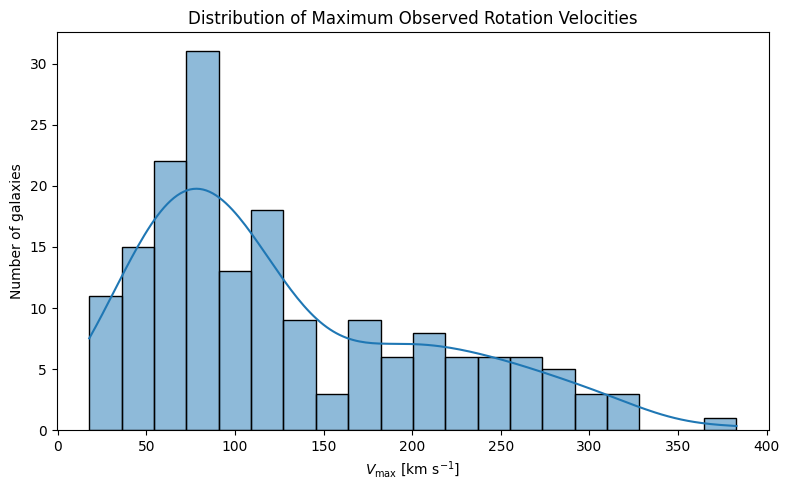

Mean Vmax: 128.39 km/s
Median Vmax: 100.00 km/s


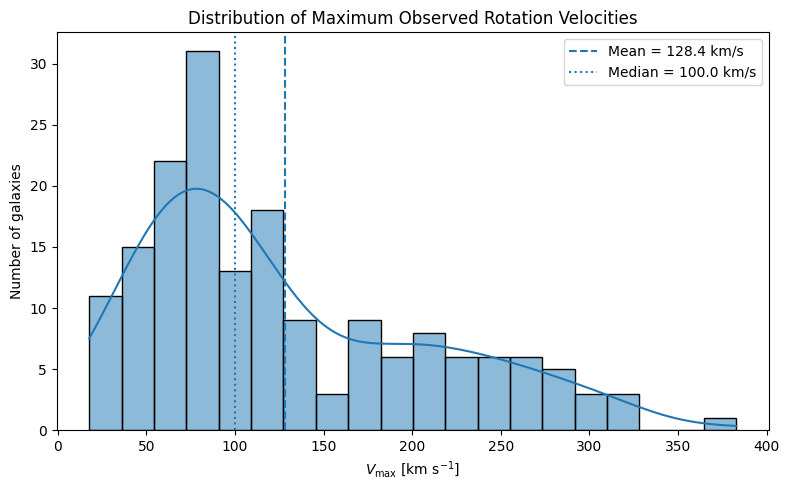

In [ ]:
#Primer panel, Distribución de velocidades máxima
plt.figure(figsize=(8, 5))

sns.histplot(
    data=plot_df,
    x="v_max_kms",
    bins=20,
    kde=True
)

plt.xlabel(r"$V_{\max}$ [km s$^{-1}$]")
plt.ylabel("Number of galaxies")
plt.title("Distribution of Maximum Observed Rotation Velocities")

plt.tight_layout()
plt.show()

#estadísticas descriptivas
vmax_mean = plot_df["v_max_kms"].mean()
vmax_median = plot_df["v_max_kms"].median()

print(f"Mean Vmax: {vmax_mean:.2f} km/s")
print(f"Median Vmax: {vmax_median:.2f} km/s")
easteregg="https://open.spotify.com/intl-es/track/0JUWF44gfMszGNhjCF7Ufs?si=b813e61663bf4229"

#Visualización
plt.figure(figsize=(8, 5))

sns.histplot(
    data=plot_df,
    x="v_max_kms",
    bins=20,
    kde=True
)

plt.axvline(
    vmax_mean,
    linestyle="--",
    label=f"Mean = {vmax_mean:.1f} km/s"
)

plt.axvline(
    vmax_median,
    linestyle=":",
    label=f"Median = {vmax_median:.1f} km/s"
)

plt.xlabel(r"$V_{\max}$ [km s$^{-1}$]")
plt.ylabel("Number of galaxies")
plt.title("Distribution of Maximum Observed Rotation Velocities")

plt.legend()
plt.tight_layout()
plt.show()

La mayoría de las galaxias de la muestra presenta velocidades máximas moderadas, mientras que un grupo menos numeroso alcanza velocidades considerablemente mayores. La media superior a la mediana refleja la influencia de esta cola de galaxias de alta velocidad.

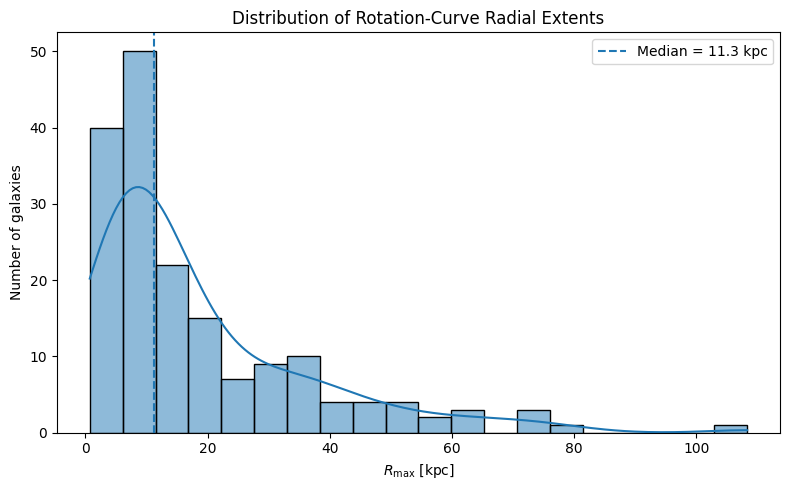

In [69]:
#Panel 2, distribución por radios
rmax_mean = plot_df["r_max_kpc"].mean()
rmax_median = plot_df["r_max_kpc"].median()

plt.figure(figsize=(8, 5))

sns.histplot(
    data=plot_df,
    x="r_max_kpc",
    bins=20,
    kde=True
)

plt.axvline(
    rmax_median,
    linestyle="--",
    label=f"Median = {rmax_median:.1f} kpc"
)

plt.xlabel(r"$R_{\max}$ [kpc]")
plt.ylabel("Number of galaxies")
plt.title("Distribution of Rotation-Curve Radial Extents")

plt.legend()
plt.tight_layout()
plt.show()

La extensión radial de las curvas de rotación es altamente heterogénea. La mayoría de las galaxias está observada hasta radios relativamente moderados, mientras que un pequeño número posee curvas mucho más extensas. Por tanto $R_{max}$ debe interpretarse tanto como una propiedad de la extensión física de la curva observada como una cantidad potencialmente influenciada por la cobertura observacional.

Slope: 3.4975
Intercept: 63.0508
Pearson r: 0.7868
R²: 0.6190
p-value: 4.2737e-38


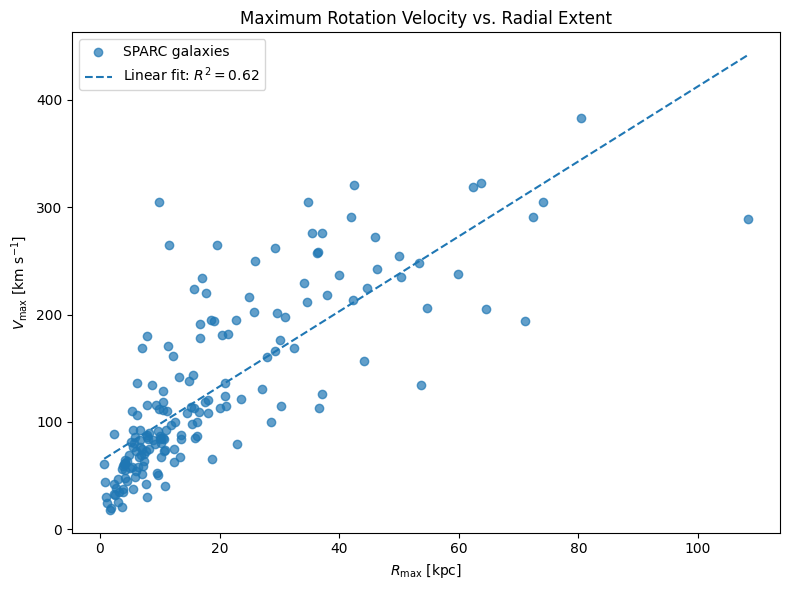

In [ ]:
#Panel 3, relación entre R_max - V_max 

#Primero hacemos la regresión lineal 
x = plot_df["r_max_kpc"].to_numpy()
y = plot_df["v_max_kms"].to_numpy()

regression = stats.linregress(x, y)

slope = regression.slope
intercept = regression.intercept
r_value = regression.rvalue
p_value = regression.pvalue

print(f"Slope: {slope:.4f}")
print(f"Intercept: {intercept:.4f}")
print(f"Pearson r: {r_value:.4f}")
print(f"R²: {r_value**2:.4f}")
print(f"p-value: {p_value:.4e}")

#Graficamos
x_fit = np.linspace(
    x.min(),
    x.max(),
    200
)

y_fit = slope * x_fit + intercept

plt.figure(figsize=(8, 6))

plt.scatter(
    x,
    y,
    alpha=0.7,
    label="SPARC galaxies"
)

plt.plot(
    x_fit,
    y_fit,
    linestyle="--",
    label=(
        rf"Linear fit: $R^2={r_value**2:.2f}$"
    )
)

plt.xlabel(r"$R_{\max}$ [kpc]")
plt.ylabel(r"$V_{\max}$ [km s$^{-1}$]")
plt.title(
    "Maximum Rotation Velocity vs. Radial Extent"
)

plt.legend()
plt.tight_layout()
plt.show()

Las galaxias cuyas curvas de rotación se extienden hasta radios mayores tienden también a alcanzar velocidades máximas más elevadas. El ajuste lineal explica aproximadamente el $62 \%$ de la variabilidad observada en $V_{max}$ aunque existe una dispersión considerable y varios objetos alejados de la tendencia principal. No creo correcto decir que $R_{max}$ causa inmediatamente $V_{max}$ ambas cantidades pueden estar relacionadas con una tercera propiedad subyacente, especialmente la escala y masa de la galaxia.

Por otro lado el punto de $110 kpc$ tiene una gran influencia potencial sobre el ajuste lineal y la considero una galaxias extrema.

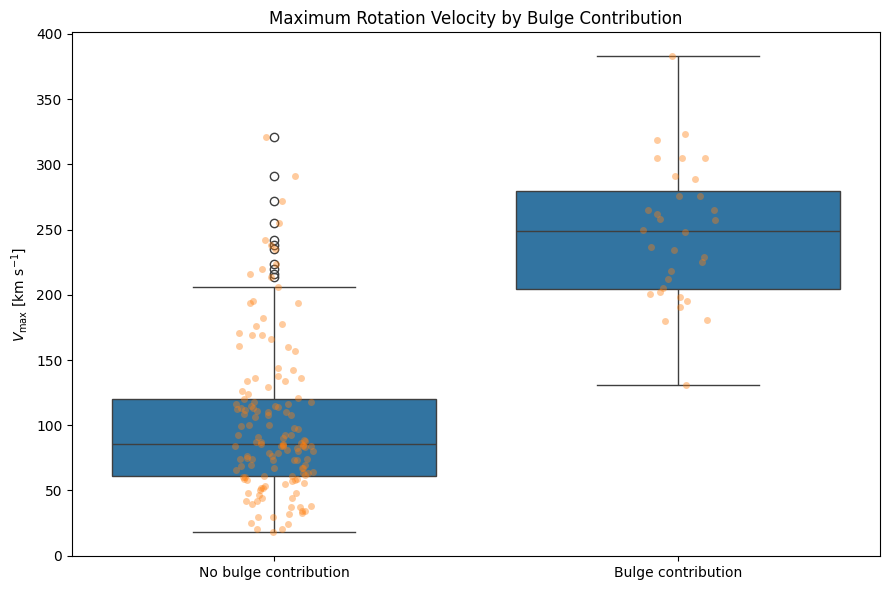

,count,mean,median,std
bulge_class,,,,
Bulge contribution,32,247.375000,249.0,52.553966
No bulge contribution,143,101.763287,85.6,59.431652


In [71]:
#Panel 4, Comparación según contribución de bulbo

#Gráfico
plt.figure(figsize=(9, 6))

sns.boxplot(
    data=plot_df,
    x="bulge_class",
    y="v_max_kms"
)

sns.stripplot(
    data=plot_df,
    x="bulge_class",
    y="v_max_kms",
    alpha=0.4
)

plt.xlabel("")
plt.ylabel(r"$V_{\max}$ [km s$^{-1}$]")
plt.title(
    "Maximum Rotation Velocity by Bulge Contribution"
)

plt.tight_layout()
plt.show()


#Estadísticas 
bulge_group_stats = (
    plot_df
    .groupby("bulge_class")["v_max_kms"]
    .agg([
        "count",
        "mean",
        "median",
        "std"
    ])
)

display(bulge_group_stats)

En la muestra SPARC analizada, las galaxias con una contribución de bulbo no nula tienden a alcanzar velocidades máximas de rotación considerablemente mayores que las galaxias sin una componente de bulbo tabulada. Esto sugiere que la presencia de un bulbo está asociada dentro de esta muestra, con sistemas de mayor escala dinámica y velocidades de rotación más elevadas. Sin embargo, esta comparación muestra una asociación y no demuestra que el bulbo sea por sí solo la causa de la mayor velocidad de rotación. No tener una contribución de bulbo tabulada no implica necesariamente una velocidad de rotación baja. 

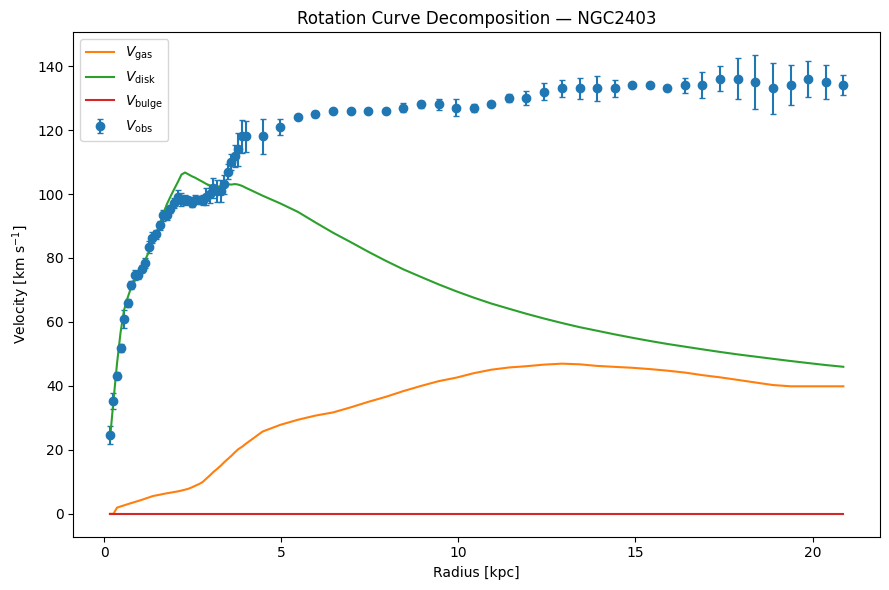

In [73]:
#Panel 5, curva de rotación representativa 
#Aquí nos toca volver a consultar SQLite, porque cerramos la conexión al final de la sección 3

#Consultamos
conn = sqlite3.connect(DATABASE_PATH)
selected_galaxy = "NGC2403"
selected_rotation_curve = pd.read_sql_query("""
SELECT
    g.name,
    g.distance_mpc,

    rc.radius_kpc,
    rc.v_obs_kms,
    rc.err_v_kms,
    rc.v_gas_kms,
    rc.v_disk_kms,
    rc.v_bulge_kms

FROM galaxies AS g

JOIN rotation_curves AS rc
    ON g.galaxy_id = rc.galaxy_id

WHERE g.name = ?

ORDER BY
    rc.radius_kpc ASC;
""",
conn,
params=(selected_galaxy,)
)

#Graficamos
plt.figure(figsize=(9, 6))

plt.errorbar(
    selected_rotation_curve["radius_kpc"],
    selected_rotation_curve["v_obs_kms"],
    yerr=selected_rotation_curve["err_v_kms"],
    fmt="o",
    capsize=2,
    label=r"$V_{\rm obs}$"
)

plt.plot(
    selected_rotation_curve["radius_kpc"],
    selected_rotation_curve["v_gas_kms"],
    label=r"$V_{\rm gas}$"
)

plt.plot(
    selected_rotation_curve["radius_kpc"],
    selected_rotation_curve["v_disk_kms"],
    label=r"$V_{\rm disk}$"
)

plt.plot(
    selected_rotation_curve["radius_kpc"],
    selected_rotation_curve["v_bulge_kms"],
    label=r"$V_{\rm bulge}$"
)

plt.xlabel(r"Radius [kpc]")
plt.ylabel(r"Velocity [km s$^{-1}$]")

plt.title(
    f"Rotation Curve Decomposition — {selected_galaxy}"
)

plt.legend()
plt.tight_layout()
plt.show()

La curva observada de $NGC2403$ permanece aproximadamente plana a grandes radios, mientras que la contribución del disco estelar disminuye. Las componentes bariónicas individuales mostradas no reproducen por sí solas la persistencia de la elevada velocidad observada en las regiones externas. Este comportamiento es característico del problema de las curvas de rotación galácticas y constituye una de las principales evidencias dinámicas utilizadas para inferir una componente de masa adicional. 

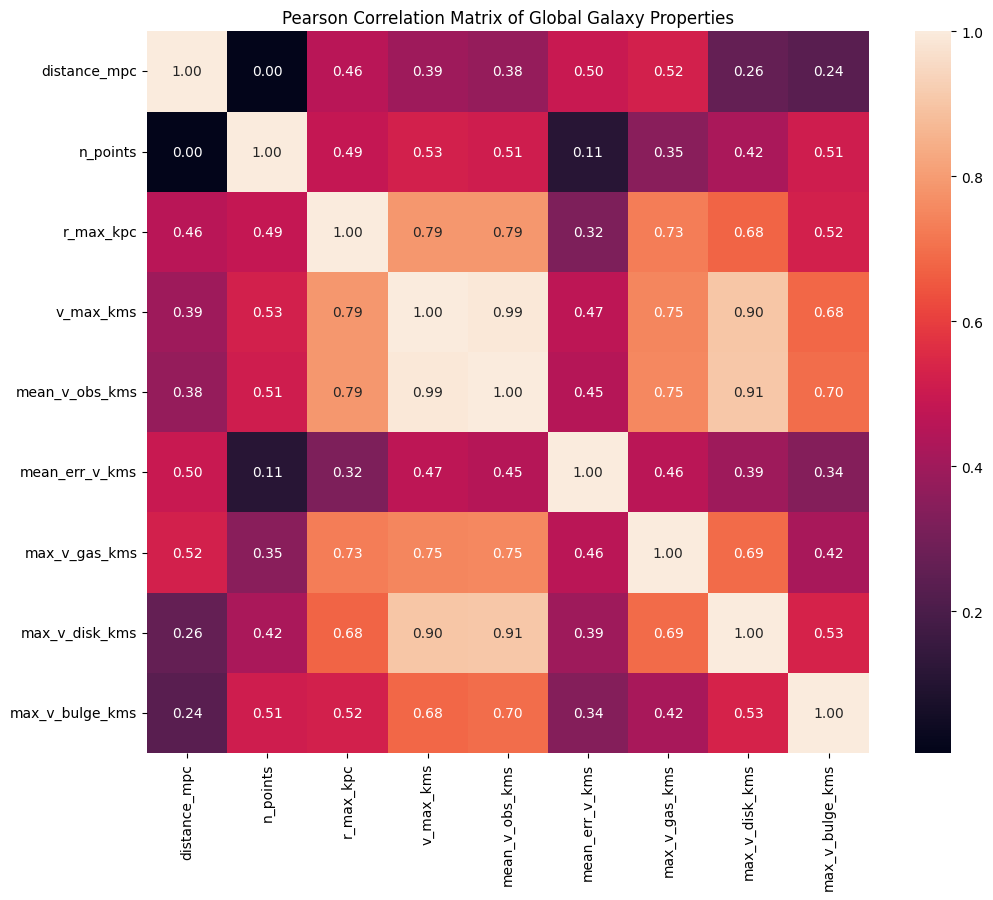

In [74]:
#Panel 6, Matriz de correlación

#seleccionamos variables
correlation_columns = [
    "distance_mpc",
    "n_points",
    "r_max_kpc",
    "v_max_kms",
    "mean_v_obs_kms",
    "mean_err_v_kms",
    "max_v_gas_kms",
    "max_v_disk_kms",
    "max_v_bulge_kms",
]

#Coeficiente de Pearson
correlation_matrix = (
    plot_df[correlation_columns]
    .corr(method="pearson")
)

#Graficamos 
plt.figure(figsize=(11, 9))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    square=True
)

plt.title(
    "Pearson Correlation Matrix of Global Galaxy Properties"
)

plt.tight_layout()
plt.show()

Las propiedades que describen la escala cinemática de las galaxias están fuertemente correlacionadas entre sí. En particular, la velocidad máxima observada presenta asociaciones fuertes con la velocidad observada media y con la contribución máxima del disco. La extensión radial también se correlaciona positivamente con la escala de velocidad. Estas correlaciones describen asociaciones dentro de la muestra y no deben interpretarse automáticamente como relaciones causales.

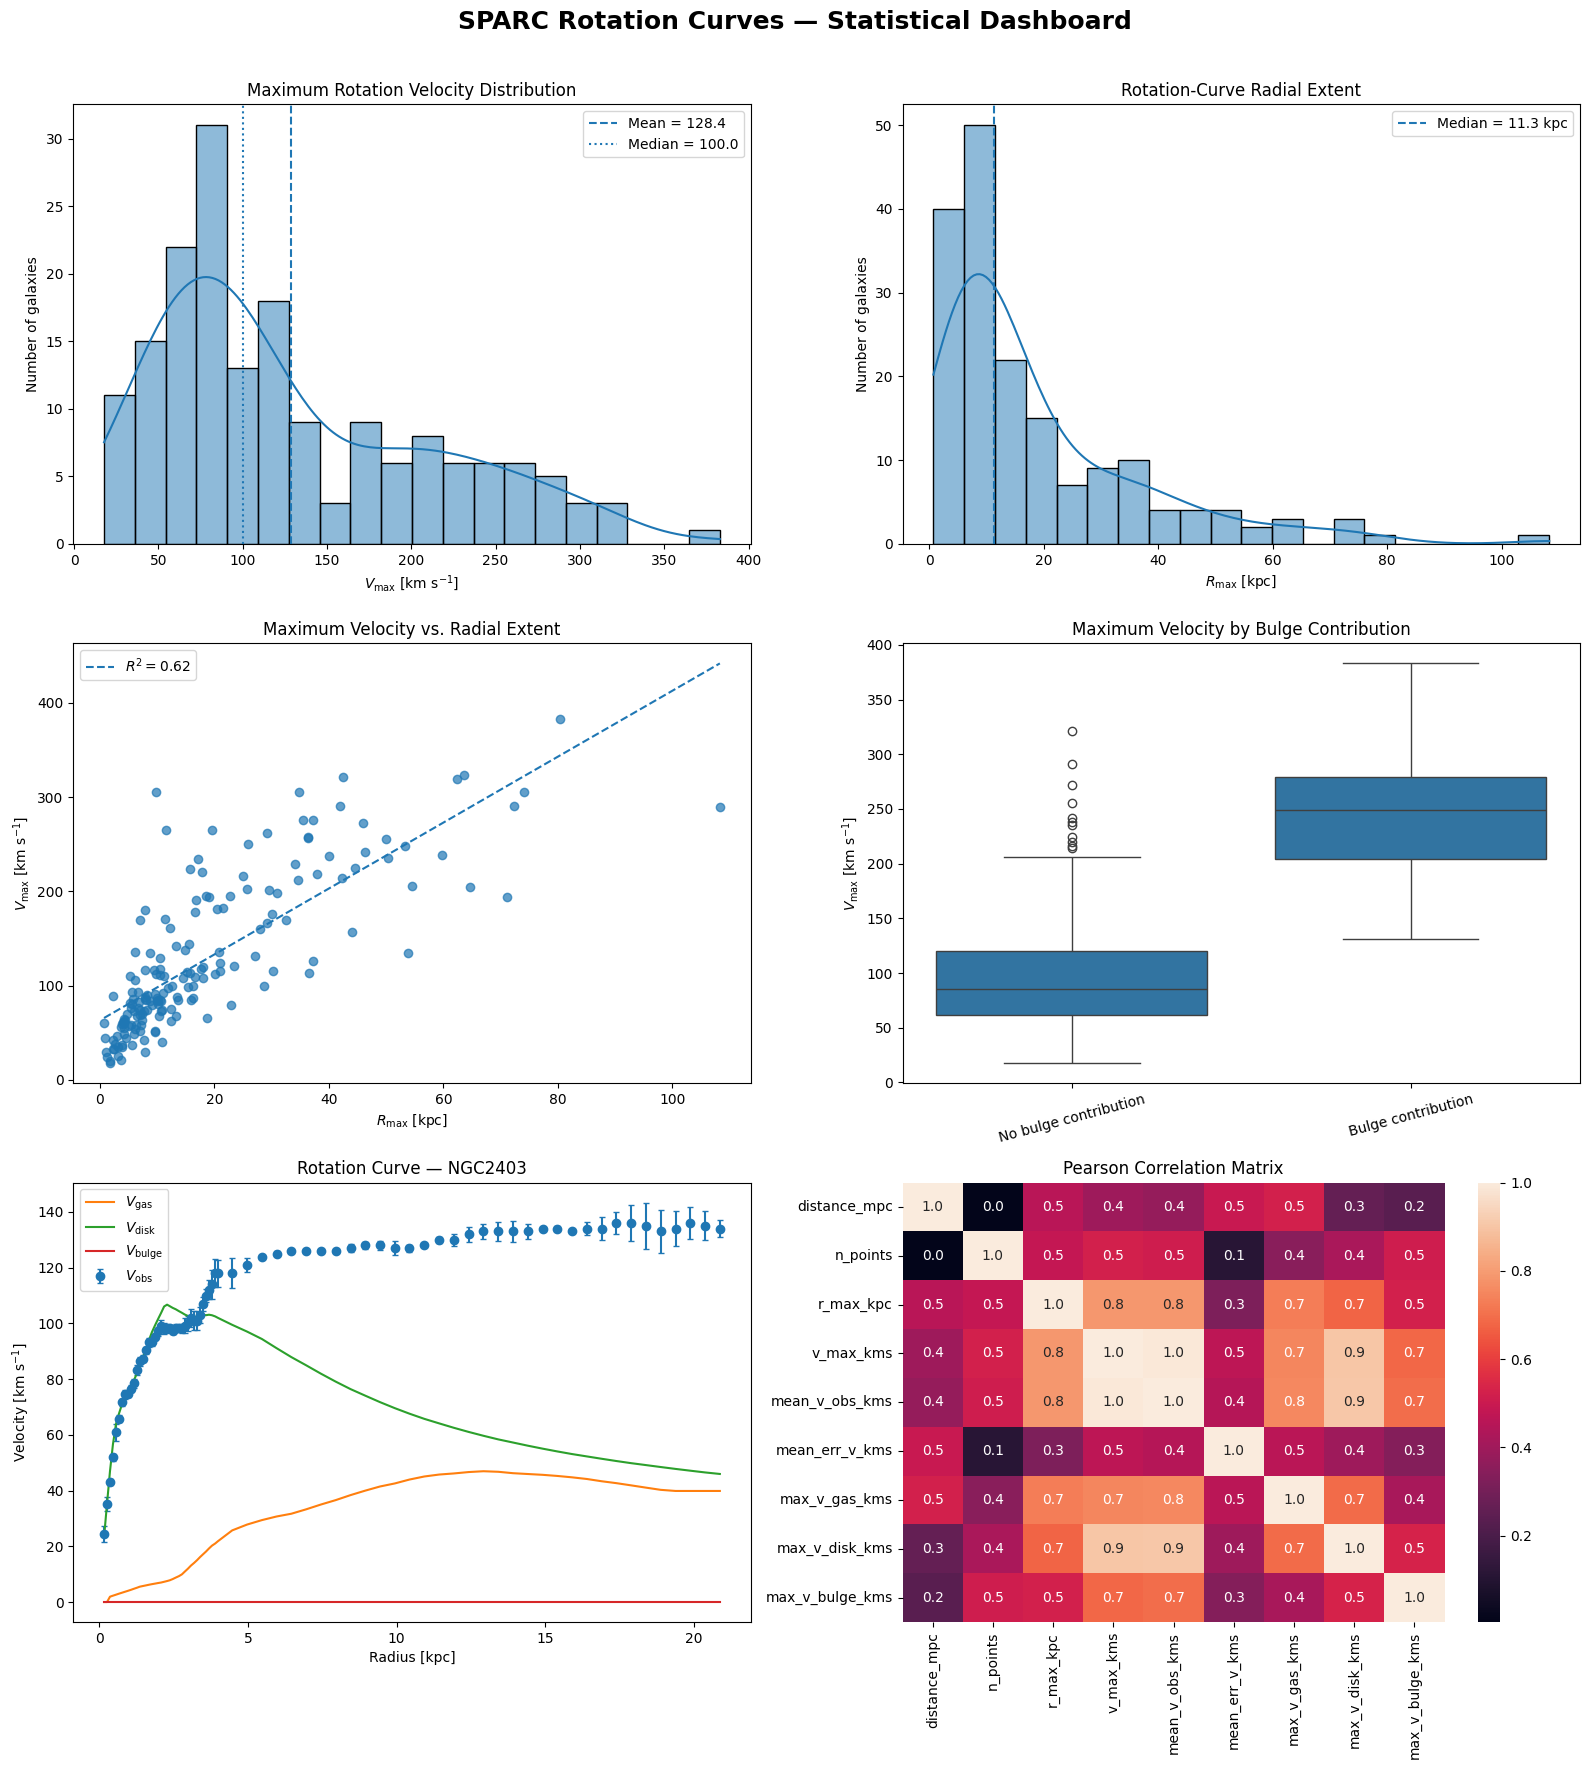

Dashboard saved to: figures/sparc_dashboard.pdf


In [75]:
#Ahora sí, lo duro, vamos a crear el Dashboard con los 6 paneles creados anterirormente 

#Reunimos las gráficas creadas
fig, axes = plt.subplots(
    3,
    2,
    figsize=(16, 18)
)

fig.suptitle(
    "SPARC Rotation Curves — Statistical Dashboard",
    fontsize=18,
    fontweight="bold"
)


#Panel 1 
ax = axes[0, 0]

sns.histplot(
    data=plot_df,
    x="v_max_kms",
    bins=20,
    kde=True,
    ax=ax
)

ax.axvline(
    vmax_mean,
    linestyle="--",
    label=f"Mean = {vmax_mean:.1f}"
)

ax.axvline(
    vmax_median,
    linestyle=":",
    label=f"Median = {vmax_median:.1f}"
)

ax.set_xlabel(r"$V_{\max}$ [km s$^{-1}$]")
ax.set_ylabel("Number of galaxies")
ax.set_title("Maximum Rotation Velocity Distribution")
ax.legend()


#Panel 2 
ax = axes[0, 1]

sns.histplot(
    data=plot_df,
    x="r_max_kpc",
    bins=20,
    kde=True,
    ax=ax
)

ax.axvline(
    rmax_median,
    linestyle="--",
    label=f"Median = {rmax_median:.1f} kpc"
)

ax.set_xlabel(r"$R_{\max}$ [kpc]")
ax.set_ylabel("Number of galaxies")
ax.set_title("Rotation-Curve Radial Extent")
ax.legend()

#Panel 3 
ax = axes[1, 0]

ax.scatter(
    x,
    y,
    alpha=0.7
)

ax.plot(
    x_fit,
    y_fit,
    linestyle="--",
    label=rf"$R^2={r_value**2:.2f}$"
)

ax.set_xlabel(r"$R_{\max}$ [kpc]")
ax.set_ylabel(r"$V_{\max}$ [km s$^{-1}$]")
ax.set_title(
    "Maximum Velocity vs. Radial Extent"
)

ax.legend()

#Panel 4 
ax = axes[1, 1]

sns.boxplot(
    data=plot_df,
    x="bulge_class",
    y="v_max_kms",
    ax=ax
)

ax.set_xlabel("")
ax.set_ylabel(r"$V_{\max}$ [km s$^{-1}$]")
ax.set_title(
    "Maximum Velocity by Bulge Contribution"
)

ax.tick_params(
    axis="x",
    rotation=15
)

#Panel 5
ax = axes[2, 0]

ax.errorbar(
    selected_rotation_curve["radius_kpc"],
    selected_rotation_curve["v_obs_kms"],
    yerr=selected_rotation_curve["err_v_kms"],
    fmt="o",
    capsize=2,
    label=r"$V_{\rm obs}$"
)

ax.plot(
    selected_rotation_curve["radius_kpc"],
    selected_rotation_curve["v_gas_kms"],
    label=r"$V_{\rm gas}$"
)

ax.plot(
    selected_rotation_curve["radius_kpc"],
    selected_rotation_curve["v_disk_kms"],
    label=r"$V_{\rm disk}$"
)

ax.plot(
    selected_rotation_curve["radius_kpc"],
    selected_rotation_curve["v_bulge_kms"],
    label=r"$V_{\rm bulge}$"
)

ax.set_xlabel("Radius [kpc]")
ax.set_ylabel(r"Velocity [km s$^{-1}$]")

ax.set_title(
    f"Rotation Curve — {selected_galaxy}"
)

ax.legend()

#Panel 6
ax = axes[2, 1]

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".1f",
    ax=ax,
    cbar=True
)

ax.set_title(
    "Pearson Correlation Matrix"
)


#Arreglo final 
plt.tight_layout(
    rect=[0, 0, 1, 0.97]
)

plt.savefig(
    DASHBOARD_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    f"Dashboard saved to: "
    f"{DASHBOARD_PATH}"
)




In [76]:
#Guardamos por último las figuras individuales para el PDF de análisis
plt.savefig(
    FIGURES_DIR / "vmax_distribution.pdf",
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

# 5. Interpretación y conclusiones:

## 5.1 Distribución de las Velocidades Máximas de Rotación

La distribución de las velocidades máximas de rotación observadas presenta asimetría positiva. La muestra tiene una velocidad máxima media de aproximadamente $128.4 km/s$ y una mediana de $100.0 km/s$. El hecho de que la media supere la mediana refleja la presencia de una cola de alta velocidad producida por un menor número de galaxias que alcanzan velocidades máximas superiores a $200-300 km/s$.

Por lo tanto, la mayoría de las galaxias de la muestra se sitúan en el rango de velocidades bajas a intermedias, mientras que los sistemas de alta velocidad son menos frecuentes. Esta distribución ilustra la amplia diversidad de escalas dinámicas representadas en la muestra SPARC.

## 5.2 Distribución de la Extensión Radial de las Curvas de Rotación

La distribución de los radios máximos medidos presenta una marcada asimetría positiva, la extensión radial mediana de las curvas de rotación es de aproximadamente $11.3 kpc$, mientras que
un número menor de galaxias presenta mediciones que superan los $40-50 kpc$, llegando el sistema más extremo a alcanzar más de $100 kpc$.

Este resultado demuestra que la cobertura radial observacional de la muestra SPARC es altamente heterogénea. Por lo tanto, la magnitud $R_{max}$ no debe interpretarse simplemente como el radio físico total de una galaxia, ya que también depende de la extensión radial sobre la cual se midió su curva de rotación.

## 5.3 Velocidad Máxima de Rotación y Extensión Radial

Se observa una clara relación positiva entre la extensión radial máxima de una curva de rotación y la velocidad máxima de rotación observada la regresión lineal
arroja un $R^2 \approx 0,62$ lo que indica que aproximadamente el 62 $\%$ de la varianza de $V_{máx}$ se explica mediante una relación lineal con $R_{máx}$ dentro de esta muestra.

Por lo tanto, las galaxias con curvas de rotación que se extienden a radios mayores tienden a alcanzar velocidades de rotación características más altas. Sin embargo, esta relación
debe interpretarse como una asociación estadística más que como una relación causal directa ambas cantidades pueden depender de propiedades subyacentes de la galaxia, como el tamaño físico y la masa total, mientras que $R_{máx}$ también puede verse influenciada por la cobertura observacional.

## 5.4 Velocidad Máxima de Rotación y Contribución del Bulbo

La distribución de las velocidades máximas de rotación difiere sustancialmente entre las galaxias con y sin contribución del bulbo en los modelos de masa SPARC.
Las galaxias con una contribución del bulbo tabulada generalmente alcanzan velocidades máximas de rotación mucho mayores, con una mediana considerablemente superior a la de las galaxias sin dicha contribución.

Este resultado indica que la presencia de una contribución del bulbo se asocia con galaxias de mayor escala dinámica de velocidad dentro de la muestra analizada sin embargo, la comparación no demuestra que el bulbo en sí mismo sea la causa directa de la mayor velocidad máxima. Las galaxias con bulbo también pueden diferir sistemáticamente en masa total y propiedades estructurales.
Varias galaxias de alta velocidad sin una contribución del bulbo tabulada también están presentes. Por lo tanto, la relación es estadística, no absoluta: una galaxia no requiere una contribución del bulbo para alcanzar una velocidad de rotación relativamente alta.

## 5.5 Descomposición de la curva de rotación de $NGC2403$

La curva de rotación observada de $NGC2403$ aumenta rápidamente en la región interior y luego se mantiene prácticamente plana a velocidades de entre $125$ y $135 km/s$ en un amplio rango radial.
En contraste, la contribución del disco estelar alcanza un máximo en la región interior y posteriormente disminuye con el radio. La contribución del gas aumenta hacia radios intermedios, pero se mantiene por debajo de la velocidad de rotación observada, mientras que la contribución tabulada del bulbo es cero.

La persistencia de una curva de rotación observada casi plana en radios grandes, a pesar de la disminución de la contribución del disco estelar, ilustra el problema clásico de la curva de rotación de las galaxias, los componentes bariónicos mostrados individualmente no reproducen las altas velocidades sostenidas observadas en las regiones exteriores,
lo que justifica la inferencia de un componente gravitacional adicional en las interpretaciones dinámicas estándar.

Los componentes de velocidad no deben sumarse directamente como velocidades lineales, en los modelos de masa, las contribuciones gravitacionales generalmente se combinan mediante sus términos de velocidad circular al cuadrado junto con la relación masa-luz apropiada para los componentes estelares; por lo tanto, esta figura debe interpretarse como una comparación de los componentes tabulados, en lugar de como un ajuste completo del modelo de masa.

## 5.6 Correlaciones entre las propiedades globales de las galaxias

La matriz de correlación revela fuertes asociaciones entre varias cantidades que caracterizan la escala dinámica de las galaxias. La velocidad de rotación máxima observada
está casi perfectamente correlacionada con la velocidad media observada y fuertemente correlacionada con la contribución máxima del disco, así como la extensión radial máxima también está correlacionada positivamente tanto con la velocidad de rotación máxima como con la media observada.

Estos resultados indican que las galaxias con mayores velocidades de rotación características tienden a tener curvas de rotación medidas más extensas y mayores contribuciones de velocidad bariónica. Sin embargo, la matriz de correlación debe interpretarse de forma descriptiva: la correlación no establece causalidad, y algunas variables están relacionadas matemática o físicamente por su propia construcción.

Por ejemplo, la fuerte correlación entre V_max y la velocidad media observada es esperable, ya que ambas cantidades se derivan de la misma curva de rotación y caracterizan su escala de velocidad global.

## 5.7 Limitaciones

Se deberían tomar en cuenta muchas limitaciones a la hora de interpretar los resultados:

1. La muestra de SPARC es una colección heterogenea de 175 galaxias del tipo "late-type" y no deberían interpretarse como una representación estadística completa de la población de galaxias. 

2. Las mediciones de radio máximo ($R_max$) dependen del rango de cobertura de la medición y no necesariamente equivalen al radio máximo real de la galaxia, en tal caso este sería el máximo registrado y el máximo real puede ser igual o mayor.

3. La magnitud $V_max$ se define aquí como la velocidad máxima observada entre las mediciones disponibles de la curva de rotación. Es una estadística descriptiva útil, pero no necesariamente representa una velocidad circular asintótica o definida teóricamente.

4. La clasificación basada en el bulbo es dependiente de la contribución de velocidad de bulbo contenida en los archivos de SPARC, no es una clasificación morfológica completa, para ello requeriríamos un estudio más profundo de la morfología galáctica que solo su contribución a la velocidad de rotación.

5. Las correlaciones entre variables no implican relaciones causales. Varias cantidades analizadas también se derivan de las mismas curvas de rotación subyacentes y, por lo tanto, no son estadísticamente independientes.

6. Los componentes individuales de la velocidad bariónica se muestran para una comparación física, pero no se combinan aquí en un modelo de masa ajustado completo, que incluya un halo de materia oscura.

## 5.8 Conclusiones

Este proyecto desarrolló un flujo de trabajo completo y reproducible para el análisis de datos del conjunto de datos de curvas de rotación de galaxias SPARC. El flujo de trabajo descarga automáticamente el archivo oficial del modelo de masa newtoniano, valida y extrae 175 archivos de galaxias, analiza 3391 mediciones de curvas de rotación, realiza controles de calidad y almacena los datos resultantes en una base de datos relacional SQLite normalizada.

Posteriormente, se utilizaron consultas SQL para recuperar y agregar propiedades de las galaxias, construir un catálogo estadístico, clasificar las galaxias según su contribución tabulada al bulbo y extraer curvas de rotación individuales. El análisis reveló distribuciones amplias y asimétricas de las velocidades máximas de rotación y las extensiones radiales, junto con una fuerte asociación positiva entre R_max y V_max. Las galaxias con una contribución tabulada al bulbo distinta de cero generalmente ocupan un rango de velocidad máxima mayor que las galaxias sin dicha contribución.

La curva de rotación de NGC2403 proporciona un ejemplo físico directo del
problema clásico de la curva de rotación: la velocidad observada se mantiene prácticamente constante en radios grandes, mientras que la contribución del disco estelar disminuye. Finalmente,
el análisis de correlación muestra que varias propiedades globales de la galaxia están
fuertemente asociadas, al tiempo que subraya la necesidad de distinguir las relaciones físicas de las correlaciones que surgen entre cantidades derivadas de los
mismos datos subyacentes.

En resumen, el proyecto demuestra el flujo de trabajo completo, desde la adquisición automática de datos y el diseño de bases de datos relacionales hasta el análisis estadístico basado en SQL, la
visualización científica y la interpretación física.